# Árbol de decisión:

In [45]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

In [46]:
data = pd.read_csv('diabetes.csv')
data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,diabetes
0,Female,80.0,0,1,never,25.19,0
1,Female,54.0,0,0,No Info,27.32,0
2,Male,28.0,0,0,never,27.32,0
3,Female,36.0,0,0,current,23.45,0
4,Male,76.0,1,1,current,20.14,0


In [47]:
diabetes = pd.read_csv('diabetes.csv')
diabetes = pd.get_dummies(diabetes)

target = 'diabetes'
X = diabetes.copy().drop(target, axis=1)
y = diabetes[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
a1 = DecisionTreeClassifier(max_depth=2, random_state=42)
a1.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [34]:
y_pred_proba_a1 = a1.predict_proba(X_test)[:,1]

auc_a1 = roc_auc_score(y_test, y_pred_proba_a1)
print(f'AUC del Árbol de Decisión: {auc_a1:.4f}')

AUC del Árbol de Decisión: 0.5942


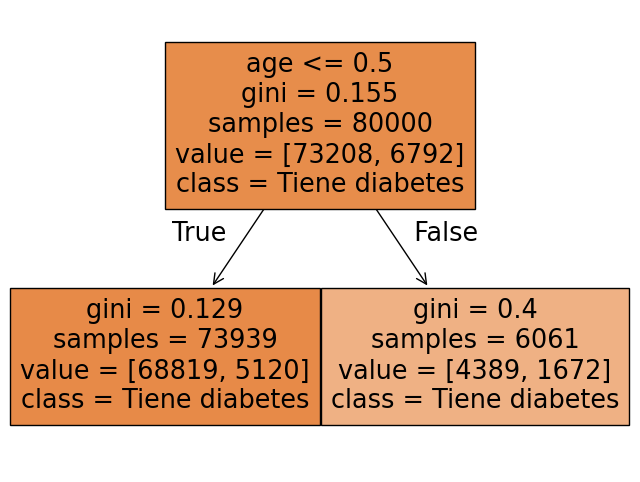

In [42]:
plt.figure(figsize=(8,6))
plot_tree(a1, feature_names=X.columns.tolist(), class_names=['Tiene diabetes', 'no tiene diabetes'], filled=True)
plt.show()

Podemos ver que el AUC de este árbol es de 0.59 lo que nos da espacio de mejora. Este auc no es suficientemente bueno para utilizar este modelo por que esto lo debemos de mejorar. Editaremos y probaremos con diferentes niveles de max_depth para mejorar e intentar incrementar el auc.

In [43]:
tree = DecisionTreeClassifier(random_state=42)
param_grid = {
    'max_depth': [2, 4, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_tree = grid_search.best_estimator_


y_pred_proba_best_tree = best_tree.predict_proba(X_test)[:, 1]

In [44]:
auc_best_tree = roc_auc_score(y_test, y_pred_proba_best_tree)
print(f'Mejores hiperparámetros: {grid_search.best_params_}')
print(f'AUC del Mejor Árbol: {auc_best_tree:.4f}')

Mejores hiperparámetros: {'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}
AUC del Mejor Árbol: 0.5942


Sin embargo, podemos ver por estos resultados que el árbol anterior es en efecto el mejor. Con un max_depth igual "2", el auc queda igual en 0.59 Como minimo se necesita una muestra y 2 splits por hoja.

# Random Forest

In [53]:
from sklearn.ensemble import RandomForestRegressor

diabetes = pd.read_csv('diabetes.csv')
diabetes = diabetes.fillna(-1)
diabetes = pd.get_dummies(diabetes, drop_first=True)
target = 'diabetes'
X = diabetes.copy().drop(target, axis=1)
y = diabetes[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [55]:
X_train.keys()

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'gender_Male',
       'gender_Other', 'smoking_history_current', 'smoking_history_ever',
       'smoking_history_former', 'smoking_history_never',
       'smoking_history_not current'],
      dtype='object')

In [57]:
pipeline = Pipeline([
    ('rf', RandomForestRegressor(n_estimators=300))
])

In [59]:
params = {
    'rf__max_depth': [6, 10, 12, 15, 20],
    'rf__max_features' :['sqrt', 'log2', 10]
}



In [ ]:
grid_rf = GridSearchCV(estimator=pipeline, cv=5, n_jobs=-1, param_grid=params, scoring='r2')
grid_rf.fit(X_train, y_train)

In [ ]:
grid_rf.best_params_
best_forest = grid_rf.best_estimator_.named_steps['rf']
predicciones = best_forest.predict(X_test)
r2_score(y_pred=predicciones, y_true=y_test)

In [ ]:
# Comparar con regresion lineal
from sklearn import linear_model

model = linear_model.LinearRegression().fit(X_train, y_train)
predicciones_lm = model.predict(X_test)
# Regresion lineal
r2_score(y_pred=predicciones_lm, y_true=y_test)

In [ ]:
importancia_variables = pd.DataFrame({
    'variable': X_train.keys(),
    'importancia': best_forest.feature_importances_
})
importancia_variables

# XGBOOST

In [ ]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
